In [87]:
#!pip install seaborn


In [1]:
import pandas as pd
from ImpararePackage import dataRequest

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns
import numpy as np


import joblib

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

In [2]:
query = """
    SELECT *
    FROM "imparare2_dataset_label_full"
    where "DIA_parsed" > to_date('2022-09-05', 'yyyy-mm-dd')
	    and "DIA_parsed" < to_date('2023-09-07', 'yyyy-mm-dd')
        and (
            "DIUR_count" is not null
            and "TEMP_count" is not null
            and "FC_count" is not null
        ) -- nao possui nenhum sinal vital 
"""

df = dataRequest.get_data(queryText= query, chunck= None)

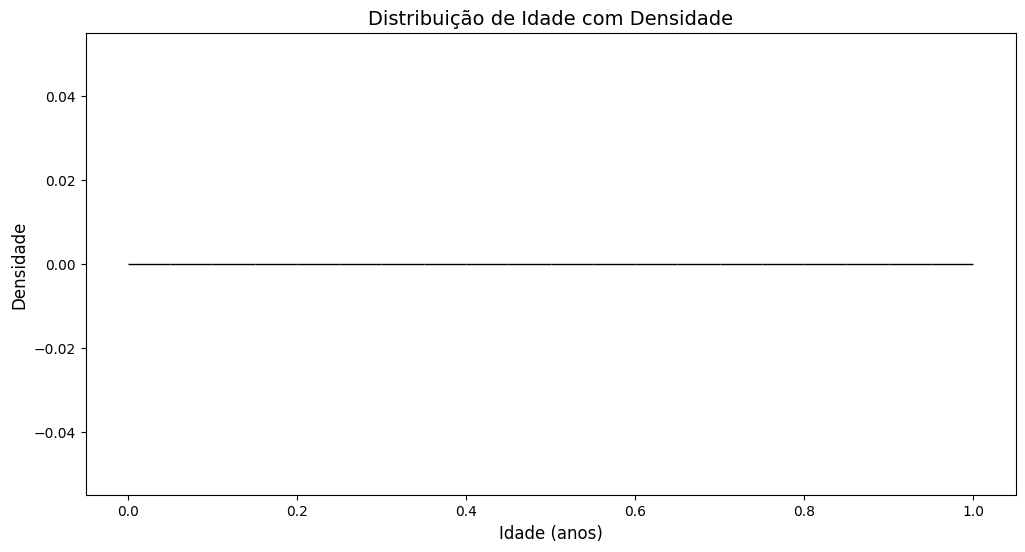

In [3]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='IDADE', bins=20, kde=True, color='blue')
plt.title('Distribuição de Idade com Densidade', fontsize=14)
plt.xlabel('Idade (anos)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.show()

In [6]:
# supondo que sua coluna se chama "idade" e está em anos (float)
pct_menor_igual_1 = (df["IDADE"] <= 1).mean() * 100

print(f"{pct_menor_igual_1:.2f}% dos pacientes têm <= 1 ano")

nan% dos pacientes têm <= 1 ano


In [7]:
df["IDADE"].describe()

count       0
unique      0
top       NaN
freq      NaN
Name: IDADE, dtype: object

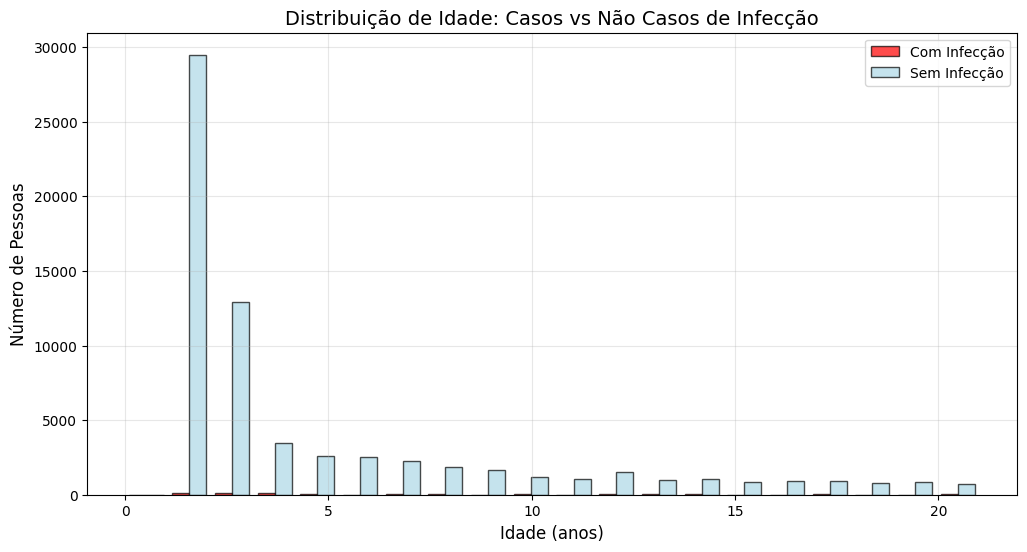

In [92]:
casos_infeccao = df[df['caso_infeccao'] == True]['IDADE']
sem_infeccao = df[df['caso_infeccao'] == False]['IDADE']

plt.figure(figsize=(12, 6))

# Plotar ambos os histogramas
plt.hist([casos_infeccao, sem_infeccao], 
         bins=20, 
         label=['Com Infecção', 'Sem Infecção'],
         color=['red', 'lightblue'],
         alpha=0.7,
         edgecolor='black')

plt.title('Distribuição de Idade: Casos vs Não Casos de Infecção', fontsize=14)
plt.xlabel('Idade (anos)', fontsize=12)
plt.ylabel('Número de Pessoas', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [93]:
df_0a2 = df[df['IDADE'] <= 2]    # 0-2 anos
df_3a12 = df[(df['IDADE'] >= 3) & (df['IDADE'] <= 12)]  # 3-12 anos  
df_13a18 = df[(df['IDADE'] >= 13) & (df['IDADE'] <= 18)] # 13-18 anos

In [94]:
# Dado controle - quem é e de quando é
dados_controle = ["REGISTRO", "DIA_parsed", "dthr_internacao", "dthr_alta"]

# Dado texto: 
dado_categoricos = ["UNIDADE_INTERNACAO", "ESPECIALIDADE_INTERNACAO", "TIPO_INTERNACAO", "CLINICA_INTERNACAO", "SEXO", "TEMP_INCUBADORA_min", "TEMP_INCUBADORA_max", "TEMP_INCUBADORA_count", "TEMP_INCUBADORA_avg", "TEMP_INCUBADORA_stddev", "TEMP_INCUBADORA_delta", "UNIDADE_fim_janela", "UNIDADE_inicio_janela", "agg_hemocultura", "agg_urocultura"]

# Gabaritos
gabaritos = ["caso_infeccao", "pnm", "isc", "itu", "pav", "ipcs", "traqueobronquite"]

# Features
features_atendimento = ["IDADE", "los_dias", "los_horas"]

features_cirurgias = ["CIRURGIA_tempo_total", "CIRURGIA_procedimentos_total"]

# Sinais vitais
features_sinal_vital = ["TECNICO(A) EM ENFERMAGEM_count", "TECNICO(A) EM ENFERMAGEM_avg", "ENFERMEIRO(A)_count", "ENFERMEIRO(A)_avg", "AUXILIAR DE ENFERMAGEM_count", "AUXILIAR DE ENFERMAGEM_avg", "ACADEMICODE ENFERMAGEM_count", "ACADEMICO DE ENFERMAGEM_avg", "MEDICO_count", "MEDICO_avg", "FISIOTERAPEUTA_count", "FISIOTERAPEUTA_avg", "OUTROS_count", "OUTROS_avg", "DIUR_min", "DIUR_max", "DIUR_count", "DIUR_avg", "DIUR_stddev", "DIUR_delta", "FC_min", "FC_max", "FC_count", "FC_avg", "FC_stddev", "FC_delta", "FR_min", "FR_max", "FR_count", "FR_avg", "FR_stddev", "FR_delta", "HGT_min", "HGT_max", "HGT_count", "HGT_avg", "HGT_stddev", "HGT_delta", "OXIMETRIA_min", "OXIMETRIA_max", "OXIMETRIA_count", "OXIMETRIA_avg", "OXIMETRIA_stddev", "OXIMETRIA_delta", "PAD_min", "PAD_max", "PAD_count", "PAD_avg", "PAD_stddev", "PAD_delta", "PAS_min", "PAS_max", "PAS_count", "PAS_avg", "PAS_stddev", "PAS_delta", "TEMP_min", "TEMP_max", "TEMP_count", "TEMP_avg", "TEMP_stddev", "TEMP_delta", "PA_min", "PA_max", "PA_count", "PA_avg", "PA_stddev", "PA_delta", "PAM_min", "PAM_max", "PAM_count", "PAM_avg", "PAM_stddev", "PAM_delta", "O2_min", "O2_max", "O2_count", "O2_avg", "O2_stddev", "O2_delta", "FIO2_min", "FIO2_max", "FIO2_count", "FIO2_avg", "FIO2_stddev", "FIO2_delta", "PEEP_min", "PEEP_max", "PEEP_count", "PEEP_avg", "PEEP_stddev", "PEEP_delta", "SINAIS_VITAIS_registros_total", "FEBRE_indicada"]

# Volumetrico evos e movimentacao
features_evol = ["UNIDADE_movimento_total", "EVOLUCAO_notas_total", "EVOLUCAO_notas_total_dia"]

# Antibioticos utilizados
features_atb = ["aciclovir_count", "amoxicilina_sulbactam_count", "cefadroxila_count", "cefalotina_count", "cefotaxima_count", "ceftazidima_count", "ceftazidima_avibactam_count", "ceftalozana_tazobactam_count", "cetoconazol_count", "claritromicina_count", "cloranfenicol_count", "doxiciclina_count", "ertapenem_count", "eritromicina_count", "ganciclovir_count", "ivermectina_count", "micafungina_count", "miconazol_count", "moxifloxacino_count", "mupirocina_count", "neomicina_count", "rifampicina_count", "sulfadiazina_count", "teicoplanina_count", "voriconazol_count", "ciprofloxacino_count", "outro_count", "amicacina_count", "amoxicilina_clavulanato_count", "amoxicilina_count", "ampicilina_count", "azitromicina_count", "penicilinagbenzatina_count", "penicilinagpotassica_count", "cefalexina_count", "cefazolina_count", "cefepima_count", "ceftriaxona_count", "cefuroxima_count", "clindamicina_count", "fluconazol_count", "gentamicina_count", "levofloxacino_count", "linezolida_count", "meropenem_count", "metronidazol_count", "nistatina_count", "oxacilina_count", "piperacilina_tazobactam_count", "ampicilina_sulbactam_count", "sulfametoxazol_trimetoprim_count", "polimixinab_count", "tobramicina_count", "vancomicina_count", "via_topico_count", "via_sng_count", "via_outro_count", "via_ev_count", "via_im_count", "via_vo_count"]

# Dados de exame
# Culturais
features_culturais = ["qtd_hemocultura_positiva", "qtd_hemocultura_sem_crescimento", "qtd_cultura_positiva", "qtd_cultura_sem_crescimento", "qtd_bacteroscopico_positiva", "qtd_bacteroscopico_negativa", "qtd_urocultura_positiva", "qtd_urocultura_sem_crescimento", "qtd_bacteriologico_positiva", "qtd_bacteriologico_sem_crescimento"]

# Sangue
features_sangue = ["leuco_min", "leuco_max", "leuco_avg", "rdw_min", "rdw_max", "rdw_avg", "neuto_min", "neuto_max", "neuto_avg"]

# Laudos Imagem
features_laudos_imagem = ["RAGIOLOGIA_laudos_total"]

# Proporção de termos no texto 
features_proporcao_texto = ["tosse", "ronco", "cavita", "opac", "infil", "fibrose_cistica", "sec_pur_pulmonar", "secr", "puru", "secr_traq", "o2", "dpoc", "hemoptise", "leucemia", "esplenectomia", "febre", "consol", "linfoma", "acinetobacter", "amarelada", "aspiracao", "broncograma_aereo", "crepitante", "enterobacter", "enterococcus", "hemophylus", "hipertermia", "imunossuprimido", "infeccao", "klebsiella", "legionella", "leucocitose", "leucopenia", "moraxella", "pneumococcus", "pseudomonas", "sibilos", "intubacao", "staphylococcus_aureus", "sepse_pulmonar", "sepse_respiratoria", "sepse_urinaria", "padrao_ventilatorio", "insuficiencia_ventilatoria", "esforco_ventilatorio", "lavado_broncoalveolar", "derrame_pleural", "escherichia_coli", "choque_septico", "dor_pleuritica", "dor_ventilatorio_dependente", "ventilacao_mecanica", "iot", "pav_1", "endoftalmite", "eritema", "hiperemia", "mediastinite", "staphylococcus_coagulase_negativo", "supuracao", "rubor", "mal_estar", "abscesso", "calor", "dreno", "edema", "endocardite", "antibiotico", "bacteriologico", "deiscencia", "resistente", "taquicardia", "cateter", "cateter_arterial", "cateter_urinario", "cvc", "cateter_venoso_periferico", "clorose", "instabilidade", "oliguria", "hipotensao", "anuria", "bacteremia", "bacteriuria", "disuria", "leucocituria", "nitrito", "svd", "tsa", "choque", "staphylococcus", "e_coli", "colecao", "tremor", "calafrio", "pos_operatorio", "dor_suprapubica", "foco_urinario", "colite_pseudomembranosa", "yersinia", "vomito", "shigella", "salmonela", "nausea", "giardia", "dor_cabeca", "dor_abdominal", "diarreia", "clostridium", "campylobacter", "urgencia_urinaria", "urgencia_miccional", "sondagem_alivio", "sondagem_vesical", "urocultura", "piuria", "albumina", "press_parc_co2", "bicarbonato", "calcio", "creatinina", "glicose", "hemoglobina", "plaquetas", "potassio", "sodio", "bilirrubina", "cardiomegalia", "lesao_pulmonar", "pneumonia", "atelectasia", "pneumotorax", "fratura", "freq_respiratoria", "freq_cardiaca", "pressao_sanguinea", "saturacao_sangue", "hemocultura", "temperatura", "ph_sangue", "propionibacterium", "cryptococcus", "pneumocystis", "histoplasma", "paracoccidioides", "bacteroides", "candida", "fusobacterium", "peptostreptococcus", "sibilancia", "hipotermia", "apneia", "bradicardia", "streptococcus_viridans", "consciencia", "hcm", "hgm", "corynebacterium", "bacillus", "aerococcus", "coccidioides", "veillonella", "covid", "peep", "fio2", "spo2", "avc", "sne", "desnutricao", "sedacao", "vsg", "fosfatase_alcalina", "ldh", "cetamina", "propofol", "clorpromazina", "fentanil", "pancuronio", "noradrenalina", "diazepan", "lorazepan", "flumazenil", "clonidina", "npt", "cateter_monolumen", "cateter_duplolumen", "cateter_triplolumen", "portocath", "cateter_hickmann", "shilley", "obesidade", "diabetes", "neutropenia", "tabagismo"]

# contagem de termos em texto
features_contagem_texto = ["tosse_pos_count", "ronco_pos_count", "cavita_pos_count", "opac_pos_count", "infil_pos_count", "fibrose_cistica_pos_count", "sec_pur_pulmonar_pos_count", "secr_pos_count", "puru_pos_count", "secr_traq_pos_count", "o2_pos_count", "dpoc_pos_count", "hemoptise_pos_count", "leucemia_pos_count", "esplenectomia_pos_count", "febre_pos_count", "consol_pos_count", "linfoma_pos_count", "acinetobacter_pos_count", "amarelada_pos_count", "aspiracao_pos_count", "broncograma_aereo_pos_count", "crepitante_pos_count", "enterobacter_pos_count", "enterococcus_pos_count", "hemophylus_pos_count", "hipertermia_pos_count", "imunossuprimido_pos_count", "infeccao_pos_count", "klebsiella_pos_count", "legionella_pos_count", "leucocitose_pos_count", "leucopenia_pos_count", "moraxella_pos_count", "pneumococcus_pos_count", "pseudomonas_pos_count", "sibilos_pos_count", "intubacao_pos_count", "staphylococcus_aureus_pos_count", "sepse_pulmonar_pos_count", "sepse_respiratoria_pos_count", "sepse_urinaria_pos_count", "padrao_ventilatorio_pos_count", "insuficiencia_ventilatoria_pos_count", "esforco_ventilatorio_pos_count", "lavado_broncoalveolar_pos_count", "derrame_pleural_pos_count", "escherichia_coli_pos_count", "choque_septico_pos_count", "dor_pleuritica_pos_count", "dor_ventilatorio_dependente_pos_count", "ventilacao_mecanica_pos_count", "iot_pos_count", "pav_pos_count", "endoftalmite_pos_count", "eritema_pos_count", "hiperemia_pos_count", "mediastinite_pos_count", "staphylococcus_coagulase_negativo_pos_count", "supuracao_pos_count", "rubor_pos_count", "mal_estar_pos_count", "abscesso_pos_count", "calor_pos_count", "dreno_pos_count", "edema_pos_count", "endocardite_pos_count", "antibiotico_pos_count", "bacteriologico_pos_count", "deiscencia_pos_count", "resistente_pos_count", "taquicardia_pos_count", "cateter_pos_count", "cateter_arterial_pos_count", "cateter_urinario_pos_count", "cvc_pos_count", "cateter_venoso_periferico_pos_count", "clorose_pos_count", "instabilidade_pos_count", "oliguria_pos_count", "hipotensao_pos_count", "anuria_pos_count", "bacteremia_pos_count", "bacteriuria_pos_count", "disuria_pos_count", "leucocituria_pos_count", "nitrito_pos_count", "svd_pos_count", "tsa_pos_count", "choque_pos_count", "staphylococcus_pos_count", "e_coli_pos_count", "colecao_pos_count", "tremor_pos_count", "calafrio_pos_count", "pos_operatorio_pos_count", "dor_suprapubica_pos_count", "foco_urinario_pos_count", "colite_pseudomembranosa_pos_count", "yersinia_pos_count", "vomito_pos_count", "shigella_pos_count", "salmonela_pos_count", "nausea_pos_count", "giardia_pos_count", "dor_cabeca_pos_count", "dor_abdominal_pos_count", "diarreia_pos_count", "clostridium_pos_count", "campylobacter_pos_count", "urgencia_urinaria_pos_count", "urgencia_miccional_pos_count", "sondagem_alivio_pos_count", "sondagem_vesical_pos_count", "urocultura_pos_count", "piuria_pos_count", "albumina_pos_count", "press_parc_co2_pos_count", "bicarbonato_pos_count", "calcio_pos_count", "creatinina_pos_count", "glicose_pos_count", "hemoglobina_pos_count", "plaquetas_pos_count", "potassio_pos_count", "sodio_pos_count", "bilirrubina_pos_count", "cardiomegalia_pos_count", "lesao_pulmonar_pos_count", "pneumonia_pos_count", "atelectasia_pos_count", "pneumotorax_pos_count", "fratura_pos_count", "freq_respiratoria_pos_count", "freq_cardiaca_pos_count", "pressao_sanguinea_pos_count", "saturacao_sangue_pos_count", "hemocultura_pos_count", "temperatura_pos_count", "ph_sangue_pos_count", "propionibacterium_pos_count", "cryptococcus_pos_count", "pneumocystis_pos_count", "histoplasma_pos_count", "paracoccidioides_pos_count", "bacteroides_pos_count", "candida_pos_count", "fusobacterium_pos_count", "peptostreptococcus_pos_count", "sibilancia_pos_count", "hipotermia_pos_count", "apneia_pos_count", "bradicardia_pos_count", "streptococcus_viridans_pos_count", "consciencia_pos_count", "hcm_pos_count", "hgm_pos_count", "corynebacterium_pos_count", "bacillus_pos_count", "aerococcus_pos_count", "coccidioides_pos_count", "veillonella_pos_count", "covid_pos_count", "peep_pos_count", "fio2_pos_count", "spo2_pos_count", "avc_pos_count", "sne_pos_count", "desnutricao_pos_count", "sedacao_pos_count", "vsg_pos_count", "fosfatase_alcalina_pos_count", "ldh_pos_count", "cetamina_pos_count", "propofol_pos_count", "clorpromazina_pos_count", "fentanil_pos_count", "pancuronio_pos_count", "noradrenalina_pos_count", "diazepan_pos_count", "lorazepan_pos_count", "flumazenil_pos_count", "clonidina_pos_count", "npt_pos_count", "cateter_monolumen_pos_count", "cateter_duplolumen_pos_count", "cateter_triplolumen_pos_count", "portocath_pos_count", "cateter_hickmann_pos_count", "shilley_pos_count", "obesidade_pos_count", "diabetes_pos_count", "neutropenia_pos_count", "tabagismo_pos_count"]


## Teste menor de 2 anos

In [95]:
df_texto_gabarito = df_13a18#[gabaritos+features_proporcao_texto]#+features_culturais+features_sangue+features_laudos_imagem+features_sinal_vital]
df_texto_gabarito.head()

,REGISTRO,DIA_parsed,SEXO,IDADE,UNIDADE_INTERNACAO,ESPECIALIDADE_INTERNACAO,TIPO_INTERNACAO,CLINICA_INTERNACAO,dthr_internacao,dthr_alta,...,cateter_monolumen_pos_count,cateter_duplolumen_pos_count,cateter_triplolumen_pos_count,portocath_pos_count,cateter_hickmann_pos_count,shilley_pos_count,obesidade_pos_count,diabetes_pos_count,neutropenia_pos_count,tabagismo_pos_count
9,845112,2023-03-23,M,15,30 INTERNACAO 12 ANDAR (C),CLINICA,EMERGENCIA,CLINICA,2023-03-04 18:24:00,2023-04-14 16:22:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
18,1628974,2023-04-19,F,13,72 INTERNAÇÃO 05 ANDAR (B),CLINICA,EMERGENCIA,CLINICA,2023-04-18 23:49:00,2023-04-20 14:44:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19,872193,2022-10-16,F,15,72 INTERNAÇÃO 05 ANDAR (B),PEDIATRIA,EMERGENCIA,PEDIATRIA,2022-10-15 21:36:00,2022-10-18 10:47:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,0.0
31,1849928,2023-09-06,M,16,45 U. CENTRO CIRURGICO (C),CIRURGICA,ELETIVA,CIRURGICA,2023-09-06 14:06:00,2023-09-07 12:38:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
54,1219695,2022-09-09,M,16,114 UNIDADE VI (SG),CLINICA,EMERGENCIA,CLINICA,2022-09-08 18:20:00,2022-09-10 14:40:00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [96]:
X_texto = df_texto_gabarito.drop(columns= gabaritos+dados_controle+dado_categoricos)
y_texto = df_texto_gabarito['caso_infeccao']
X_texto_train, X_texto_test, y_texto_train, y_texto_test = train_test_split(X_texto, y_texto, test_size=0.33, random_state=42, stratify= y_texto)
len(X_texto_train), len(X_texto_test), len(y_texto_train), len(y_texto_test)

(3761, 1853, 3761, 1853)

In [97]:
# X = df.drop(columns= ["avc","TEMP_INCUBADORA_min", "TEMP_INCUBADORA_max", "TEMP_INCUBADORA_count", "TEMP_INCUBADORA_avg", "TEMP_INCUBADORA_stddev", "TEMP_INCUBADORA_delta",'REGISTRO', 'los_horas', 'caso_infeccao', 'pnm', 'isc', 'itu', 'pav', 'ipcs', 'traqueobronquite', 'DIA_parsed', 'SEXO', 'UNIDADE_INTERNACAO', 'UNIDADE_INTERNACAO', 'ESPECIALIDADE_INTERNACAO', 'TIPO_INTERNACAO',	'CLINICA_INTERNACAO', 'dthr_internacao', 'dthr_alta', 'UNIDADE_fim_janela', 'UNIDADE_inicio_janela', 'agg_hemocultura', 'agg_urocultura'])
# y = df['caso_infeccao']
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify= y)

In [107]:
model = DecisionTreeClassifier(
    criterion='entropy', 
    splitter='random', 
    # random_state= 20, 
    min_samples_leaf= 1,
    # min_samples_split= 3,
    # max_features= None,
    # max_depth= 18,
    class_weight= {0: 1, 1: 200}
)

model.fit(X_texto_train, y_texto_train)

,criterion,'entropy'
,splitter,'random'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,"{0: 1, 1: 200}"


In [108]:
y_train_pred = model.predict(X_texto_train)
acc = accuracy_score(y_train_pred, y_texto_train)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_train_pred, y_texto_train)
print(f"Confusion Matrix treino: \n{cm}\n")
report = classification_report(y_train_pred, y_texto_train)
print(report)

print("\n=========================================================\n")
# Validando test
y_pred = model.predict(X_texto_test)
    
acc = accuracy_score(y_pred, y_texto_test)
print(f"Accurácia: {acc}")
cm = confusion_matrix(y_pred, y_texto_test)
print(f"Confusion Matrix teste: \n{cm}")
report = classification_report(y_pred, y_texto_test)
print(report)

Accurácia: 1.0
Confusion Matrix treino: 
[[3685    0]
 [   0   76]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3685
           1       1.00      1.00      1.00        76

    accuracy                           1.00      3761
   macro avg       1.00      1.00      1.00      3761
weighted avg       1.00      1.00      1.00      3761



Accurácia: 0.9908256880733946
Confusion Matrix teste: 
[[1803    5]
 [  12   33]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1808
           1       0.87      0.73      0.80        45

    accuracy                           0.99      1853
   macro avg       0.93      0.87      0.90      1853
weighted avg       0.99      0.99      0.99      1853

